# Abyan Grocery Sales 2024
## Python Data Analysis Project
### Prepared by: Abdulkadir Dhaffe

This project analyzes Abyan Grocery sales data for 2024 through a complete Python data analysis workflow:

**Raw Data → Inspection → Data Tracking → Data Cleaning & Preparation → EDA → Visualization → Insights → Recommendations**

### Executive Summary

Abyan Grocery generated approximately **32,700.87** in total sales across **4,472 orders**, with an average order value of approximately **7.31**. The analysis shows a clear concentration of sales across branches, product categories, and periods. **Hodan-Taleh** was the strongest-performing branch, contributing about **48.6% of total sales**, while **Household** was the leading category with approximately **8,122.74** in sales. At product level, **Rice 5kg** was the top-selling product, generating approximately **3,128.50**. Sales also showed a noticeable improvement toward the end of the year: **December** recorded the highest monthly sales at approximately **3,688.14**, while **September** was the lowest month at approximately **2,210.76**. Payment behavior was highly concentrated, with **EVC Plus** accounting for about **51.8% of orders**, making it the most preferred payment method. These findings suggest opportunities to strengthen lower-performing branches, maintain availability of high-performing household and staple products, prepare inventory for stronger year-end demand, and continue supporting the payment methods customers use most frequently. Overall, the analysis demonstrates how cleaned transactional data can be transformed into practical business insights for decision-making.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path
import pandas as pd

# Change this only if you move the original workbook.
DATA_PATH = Path(r"C:\Users\Ccxtall\OneDrive\Documents\Abyan_Grocery_Sales_2024.csv.xlsx")
OUTPUT_DIR = Path("data")
OUTPUT_DIR.mkdir(exist_ok=True)

In [3]:
df = pd.read_excel(DATA_PATH)
df.head(10)

,Invoice_ID,Date,Branch,Category,Product_Name,Customer_Type,Gender,Quantity,Unit_Price,Sales,Payment_Method,Cashier
0,INV100112,2024-01-01,Hodan-Taleex,Personal Care,Body Lotion 200ml,Member,Male,3,2.80,8.40,EVC Plus,Amina Hassan
1,INV100223,2024-01-01,Hodan-Taleex,Personal Care,Toothpaste,Member,Female,5,2.14,10.70,EVC Plus,Amina Hassan
2,INV100161,2024-01-01,Hamar Weyne,Bakery,White Bread,Regular,Female,5,0.93,4.65,EVC Plus,Khadija Omar
3,INV100249,2024-01-01,Hodan-Taleex,Personal Care,Body Lotion 200ml,Regular,Female,3,2.99,8.97,EVC Plus,Mohamed Ali
4,INV100115,2024-01-01,Hodan-Taleex,Personal Care,Hand Sanitizer 100ml,Regular,Male,3,1.31,3.93,EVC Plus,Amina Hassan
5,INV100002,2024-01-01,Hamar Weyne,Household,Laundry Detergent 1kg,Member,Male,6,3.13,18.78,EVC Plus,Hodan Warsame
6,INV100061,2024-01-01,Hodan-Taleex,Beverages,Black Tea Pack,Member,Female,8,1.28,10.24,Cash,Amina Hassan
7,INV100201,2024-01-01,Hodan-Taleex,Snacks,Peanuts 200g,Member,Female,2,1.27,2.54,EVC Plus,Abdirahman Nur
8,INV100106,2024-01-01,Hamar Weyne,Beverages,Orange Juice 1L,Regular,Female,5,2.06,10.30,EVC Plus,Ahmed Abdi
9,INV100240,2024-01-01,Laba Dhagax,Beverages,Sprite 500ml,Member,Male,7,1.07,7.49,Zaad,Yusuf Farah


### Step 2 Data Tracking 

In [4]:
# Step 1 — Dataset size

print("Rows iyo Columns:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Rows iyo Columns: (4500, 12)
Number of rows: 4500
Number of columns: 12


In [5]:
#Step 2 — Column names

df.columns.tolist()

['Invoice_ID',
 'Date',
 'Branch',
 'Category',
 'Product_Name',
 'Customer_Type',
 'Gender',
 'Quantity',
 'Unit_Price',
 'Sales',
 'Payment_Method',
 'Cashier']

In [6]:
# Step 3 — Data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Invoice_ID      4500 non-null   object        
 1   Date            4500 non-null   datetime64[ns]
 2   Branch          4500 non-null   object        
 3   Category        4496 non-null   object        
 4   Product_Name    4500 non-null   object        
 5   Customer_Type   4500 non-null   object        
 6   Gender          4500 non-null   object        
 7   Quantity        4500 non-null   int64         
 8   Unit_Price      4500 non-null   float64       
 9   Sales           4500 non-null   float64       
 10  Payment_Method  4495 non-null   object        
 11  Cashier         4496 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(8)
memory usage: 422.0+ KB


In [7]:
# Step 4 — Missing Values

missing_values = df.isnull().sum()
missing_values

Invoice_ID        0
Date              0
Branch            0
Category          4
Product_Name      0
Customer_Type     0
Gender            0
Quantity          0
Unit_Price        0
Sales             0
Payment_Method    5
Cashier           4
dtype: int64

In [8]:
# Step 5 — Duplicates

df.duplicated().sum()

np.int64(15)

In [9]:
# Step 6 — Unique values

df.nunique()

Invoice_ID        4485
Date               366
Branch               7
Category            12
Product_Name        54
Customer_Type        6
Gender               6
Quantity             8
Unit_Price         524
Sales             1288
Payment_Method      15
Cashier             17
dtype: int64

In [10]:
# Step 7 — Inspect categorical columns

for col in df.select_dtypes(include="object"):
    print("\n---", col, "---")
    print(df[col].value_counts(dropna=False))


--- Invoice_ID ---
Invoice_ID
INV103244    2
INV101190    2
INV101111    2
INV101742    2
INV101430    2
            ..
INV101709    1
INV101385    1
INV101410    1
INV101543    1
INV104211    1
Name: count, Length: 4485, dtype: int64

--- Branch ---
Branch
Hodan-Taleex        2196
Hamar Weyne         1381
Laba Dhagax          917
Hodan-Taleex           2
   Hodan-Taleex        2
  Hodan-Taleex         1
  Hamar Weyne          1
Name: count, dtype: int64

--- Category ---
Category
Beverages        672
Household        617
Personal Care    568
Bakery           558
Vegetables       557
Snacks           523
Dairy            505
Fruits           492
NaN                4
   Household       1
   Snacks          1
   Dairy           1
Household          1
Name: count, dtype: int64

--- Product_Name ---
Product_Name
Body Lotion 200ml        113
Brown Bread              110
Candy Pack               108
Biscuits Pack            104
Sprite 500ml             104
Bar Soap                 103
Tomat

In [11]:
# Step 8 — Numeric data tracking

df.describe()
df[["Quantity", "Unit_Price", "Sales"]].describe().round(2)

,Quantity,Unit_Price,Sales
count,4500.00,4500.00,4500.00
mean,4.06,1.80,7.31
std,1.98,1.36,7.18
min,1.00,0.30,0.31
25%,2.00,0.89,2.94
50%,4.00,1.28,5.12
75%,6.00,2.35,9.12
max,8.00,9.49,75.84


In [12]:
# Step 9 — Date tracking

print("Start Date:", df["Date"].min())
print("End Date:", df["Date"].max())

df["Date"].isnull().sum()

Start Date: 2024-01-01 00:00:00
End Date: 2024-12-31 00:00:00


np.int64(0)

In [13]:
# Step 10 — Data Tracking Summary

data_tracking = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values})

data_tracking

,Column,Data Type,Missing Values,Unique Values
0,Invoice_ID,object,0,4485
1,Date,datetime64[ns],0,366
2,Branch,object,0,7
3,Category,object,4,12
4,Product_Name,object,0,54
5,Customer_Type,object,0,6
6,Gender,object,0,6
7,Quantity,int64,0,8
8,Unit_Price,float64,0,524
9,Sales,float64,0,1288


### Step 3 Data Cleaning and Preparation 

In [14]:
import pandas as pd

In [15]:
df_clean = df.copy()

In [16]:
# Cleaning Step 1 — Remove Exact Duplicates 'before'

df_clean[df_clean.duplicated()]
df_clean.duplicated().sum()

np.int64(15)

In [17]:
df_clean = df_clean.drop_duplicates()

In [18]:
df_clean.duplicated().sum()

np.int64(0)

In [19]:
# Cleaning Step 2 — Standardize Text Spaces

df_clean["Branch"].unique()

array(['Hodan-Taleex', 'Hamar Weyne', 'Laba Dhagax', '  Hodan-Taleex  ',
       'Hodan-Taleex   ', '   Hodan-Taleex', '  Hamar Weyne  '],
      dtype=object)

In [20]:
text_columns = df_clean.select_dtypes(include="object").columns
for col in text_columns: df_clean[col] = df_clean[col].str.strip()

In [21]:
df_clean["Branch"].value_counts(dropna=False)

Branch
Hodan-Taleex    2194
Hamar Weyne     1375
Laba Dhagax      916
Name: count, dtype: int64

In [22]:
df_clean["Branch"].unique()

array(['Hodan-Taleex', 'Hamar Weyne', 'Laba Dhagax'], dtype=object)

In [23]:
# Cleaning Step 3 — Standardize Gender

df_clean["Gender"].unique()

array(['Male', 'Female', 'M', 'FEMALE', 'MALE', 'F'], dtype=object)

In [24]:
df_clean["Gender"] = (df_clean["Gender"].str.strip().str.upper().replace
    ({"M": "MALE","MALE": "MALE","F": "FEMALE","FEMALE": "FEMALE"}).str.title())

In [25]:
df_clean["Gender"].value_counts(dropna=False)

Gender
Female    2251
Male      2234
Name: count, dtype: int64

In [26]:
# Cleaning Step 4 — Customer Type

df_clean["Customer_Type"].unique()

array(['Member', 'Regular', 'Mem', 'Reg'], dtype=object)

In [27]:
df_clean["Customer_Type"] = (
    df_clean["Customer_Type"]
    .str.strip()
    .str.lower()
    .replace({
        "mem": "member",
        "member": "member",
        "reg": "regular",
        "regular": "regular"}).str.title())

In [28]:
df_clean["Customer_Type"].value_counts(dropna=False)

Customer_Type
Regular    2658
Member     1827
Name: count, dtype: int64

In [29]:
# Cleaning Step 5 — Payment Method

df_clean["Payment_Method"].unique()

array(['EVC Plus', 'Cash', 'Zaad', 'EVC', 'evc', 'C', 'Visa Card', 'cash',
       'visa card', 'evc plus', 'Visa', 'VISA', nan], dtype=object)

In [30]:
df_clean["Payment_Method"] = (
    df_clean["Payment_Method"]
    .str.strip()
    .str.lower()
    .replace({
        "evc": "evc plus",
        "evc plus": "evc plus",
        "cash": "cash",
        "c": "cash",
        "visa": "visa",
        "visa card": "visa",
        "zaad": "zaad"
    }).str.title())

In [31]:
df_clean["Payment_Method"].value_counts(dropna=False)

Payment_Method
Evc Plus    2318
Zaad        1091
Cash         652
Visa         419
NaN            5
Name: count, dtype: int64

In [32]:
# Cleaning Step 6 — Branch extra spaces

df_clean["Category"].unique()

array(['Personal Care', 'Bakery', 'Household', 'Beverages', 'Snacks',
       'Fruits', 'Vegetables', 'Dairy', nan], dtype=object)

In [33]:
df_clean["Category"].value_counts(dropna=False)

Category
Beverages        671
Household        617
Personal Care    567
Bakery           557
Vegetables       556
Snacks           519
Dairy            505
Fruits           489
NaN                4
Name: count, dtype: int64

In [34]:
# Cleaning Step 8 — Cashier extra spaces

df_clean["Cashier"].unique()

array(['Amina Hassan', 'Khadija Omar', 'Mohamed Ali', 'Hodan Warsame',
       'Abdirahman Nur', 'Ahmed Abdi', 'Yusuf Farah', 'Fadumo Yusuf',
       'Sahra Ibrahim', nan], dtype=object)

In [35]:
df_clean["Cashier"].value_counts(dropna=False)

Cashier
Fadumo Yusuf      570
Abdirahman Nur    551
Amina Hassan      538
Mohamed Ali       531
Ahmed Abdi        477
Sahra Ibrahim     471
Khadija Omar      458
Yusuf Farah       445
Hodan Warsame     440
NaN                 4
Name: count, dtype: int64

#### Handling Missing Values

In [36]:
df_clean.isnull().sum()

Invoice_ID        0
Date              0
Branch            0
Category          4
Product_Name      0
Customer_Type     0
Gender            0
Quantity          0
Unit_Price        0
Sales             0
Payment_Method    5
Cashier           4
dtype: int64

In [37]:
# Category — 4 missing
df_clean[df_clean["Category"].isna()]

,Invoice_ID,Date,Branch,Category,Product_Name,Customer_Type,Gender,Quantity,Unit_Price,Sales,Payment_Method,Cashier
194,INV100141,2024-01-19,Hamar Weyne,NaN,Sprite 500ml,Regular,Male,2,0.82,1.64,Evc Plus,Khadija Omar
1208,INV101311,2024-04-16,Laba Dhagax,NaN,Cabbage (each),Member,Male,4,1.20,4.80,Zaad,Yusuf Farah
2316,INV102359,2024-07-18,Hamar Weyne,NaN,Sugar 2kg,Member,Male,4,2.88,11.52,Zaad,Hodan Warsame
3242,INV103294,2024-10-11,Hamar Weyne,NaN,White Bread,Regular,Male,6,0.77,4.62,Zaad,Ahmed Abdi


In [38]:
df_clean.loc[
    df_clean["Category"].isna(),
    ["Invoice_ID", "Product_Name", "Category"]]

,Invoice_ID,Product_Name,Category
194,INV100141,Sprite 500ml,NaN
1208,INV101311,Cabbage (each),NaN
2316,INV102359,Sugar 2kg,NaN
3242,INV103294,White Bread,NaN


In [39]:
# Payment Method — 5 missing
df_clean[df_clean["Payment_Method"].isna()]

,Invoice_ID,Date,Branch,Category,Product_Name,Customer_Type,Gender,Quantity,Unit_Price,Sales,Payment_Method,Cashier
1064,INV101187,2024-04-05,Hodan-Taleex,Vegetables,Onion (kg),Regular,Female,6,0.66,3.96,NaN,Fadumo Yusuf
2131,INV101929,2024-06-30,Hodan-Taleex,Beverages,Coffee 200g,Regular,Male,2,3.96,7.92,NaN,Abdirahman Nur
2480,INV102621,2024-08-02,Hodan-Taleex,Snacks,Potato Chips,Member,Female,8,1.09,8.72,NaN,Fadumo Yusuf
2546,INV102771,2024-08-08,Hodan-Taleex,Beverages,Soft Drink Cola 500ml,Member,Male,5,0.77,3.85,NaN,Amina Hassan
2568,INV102478,2024-08-11,Hodan-Taleex,Household,Cooking Oil 1L,Member,Female,2,2.51,5.02,NaN,Amina Hassan


In [40]:
df_clean.loc[
    df_clean["Payment_Method"].isna(),
    ["Invoice_ID", "Sales", "Payment_Method"]]

,Invoice_ID,Sales,Payment_Method
1064,INV101187,3.96,NaN
2131,INV101929,7.92,NaN
2480,INV102621,8.72,NaN
2546,INV102771,3.85,NaN
2568,INV102478,5.02,NaN


In [41]:
# Cashier — 4 missing
df_clean[df_clean["Cashier"].isna()]

,Invoice_ID,Date,Branch,Category,Product_Name,Customer_Type,Gender,Quantity,Unit_Price,Sales,Payment_Method,Cashier
946,INV100809,2024-03-24,Hodan-Taleex,Dairy,Fresh Cream 200ml,Regular,Male,3,1.60,4.80,Evc Plus,NaN
3402,INV103136,2024-10-22,Hodan-Taleex,Bakery,Biscuits Pack,Member,Female,8,0.96,7.68,Zaad,NaN
4176,INV104323,2024-12-13,Hodan-Taleex,Personal Care,Toothbrush,Regular,Female,1,1.35,1.35,Zaad,NaN
4448,INV104371,2024-12-29,Hodan-Taleex,Dairy,Butter 250g,Regular,Female,4,2.20,8.80,Evc Plus,NaN


In [42]:
# Numeric Validation

In [43]:
print("Negative Quantity:", (df_clean["Quantity"] < 0).sum())
print("Zero Quantity:", (df_clean["Quantity"] == 0).sum())

print("Invalid Unit Price:", (df_clean["Unit_Price"] <= 0).sum())

print("Invalid Sales:", (df_clean["Sales"] <= 0).sum())

Negative Quantity: 0
Zero Quantity: 0
Invalid Unit Price: 0
Invalid Sales: 0


In [44]:
# Sales Validation

In [45]:
df_clean["Calculated_Sales"] = (
    df_clean["Quantity"] * df_clean["Unit_Price"])

df_clean["Sales_Difference"] = (
    df_clean["Sales"] - df_clean["Calculated_Sales"])

df_clean["Sales_Difference"].abs().sum()

np.float64(9.630074515598608e-13)

In [46]:
df_clean.drop(
    columns=["Calculated_Sales", "Sales_Difference"],inplace=True)

In [47]:
# Date Preparation

df_clean["Date"] = pd.to_datetime(df_clean["Date"])

In [48]:
df_clean["Date"].dtype

dtype('<M8[ns]')

In [49]:
df_clean["Year"] = df_clean["Date"].dt.year
df_clean["Month"] = df_clean["Date"].dt.month
df_clean["Month_Name"] = df_clean["Date"].dt.month_name()

In [50]:
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])
print("Duplicates:", df_clean.duplicated().sum())
print("\nMissing Values:")
print(df_clean.isnull().sum())

Rows: 4485
Columns: 15
Duplicates: 0

Missing Values:
Invoice_ID        0
Date              0
Branch            0
Category          4
Product_Name      0
Customer_Type     0
Gender            0
Quantity          0
Unit_Price        0
Sales             0
Payment_Method    5
Cashier           4
Year              0
Month             0
Month_Name        0
dtype: int64


In [51]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4485 entries, 0 to 4499
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Invoice_ID      4485 non-null   object        
 1   Date            4485 non-null   datetime64[ns]
 2   Branch          4485 non-null   object        
 3   Category        4481 non-null   object        
 4   Product_Name    4485 non-null   object        
 5   Customer_Type   4485 non-null   object        
 6   Gender          4485 non-null   object        
 7   Quantity        4485 non-null   int64         
 8   Unit_Price      4485 non-null   float64       
 9   Sales           4485 non-null   float64       
 10  Payment_Method  4480 non-null   object        
 11  Cashier         4481 non-null   object        
 12  Year            4485 non-null   int32         
 13  Month           4485 non-null   int32         
 14  Month_Name      4485 non-null   object        
dtypes: dateti

In [52]:
# Removing mising value without 
# Missing Values: The dataset contained 13 missing values across Category, Payment Method, and Cashier. 
# Since these represented a very small proportion of the dataset, 
# the affected records were removed rather than introducing potentially inaccurate values.

In [53]:
df_clean.isnull().sum()

Invoice_ID        0
Date              0
Branch            0
Category          4
Product_Name      0
Customer_Type     0
Gender            0
Quantity          0
Unit_Price        0
Sales             0
Payment_Method    5
Cashier           4
Year              0
Month             0
Month_Name        0
dtype: int64

In [54]:
df_clean = df_clean.dropna()

In [55]:
print("Rows after removing missing values:", df_clean.shape[0])
print("Total Missing Values:", df_clean.isnull().sum().sum())

Rows after removing missing values: 4472
Total Missing Values: 0


### Save the Cleaned Dataset

The cleaned dataset is exported as a separate CSV file so that the output of the cleaning stage can be reused for analysis and reporting.

In [56]:
# Save cleaned dataset
CLEANED_FILE = "Abyan_Grocery_Sales_Cleaned.csv"
df_clean.to_csv(CLEANED_FILE, index=False)

print(f"Cleaned dataset saved as: {CLEANED_FILE}")
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

Cleaned dataset saved as: Abyan_Grocery_Sales_Cleaned.csv
Rows: 4472
Columns: 15


In [ ]:
Raw Data
   ↓
Inspection
   ↓
Data Tracking
   ↓
Remove Duplicates → 15
   ↓
Handle Inconsistent Text
   ↓
Handle Missing Values → 13 removed
   ↓
Data Validation
   ↓
Clean Dataset → 4,472 rows

## EDA Exploretary Data Analyses

In [58]:
# Step 1 EDA Overview
df_clean.shape

(4472, 15)

In [59]:
df.columns.tolist()

['Invoice_ID',
 'Date',
 'Branch',
 'Category',
 'Product_Name',
 'Customer_Type',
 'Gender',
 'Quantity',
 'Unit_Price',
 'Sales',
 'Payment_Method',
 'Cashier']

In [60]:
# STEP 2 — Statistical Overview
df_clean.describe()

,Date,Quantity,Unit_Price,Sales,Year,Month
count,4472,4472.000000,4472.000000,4472.000000,4472.0,4472.000000
mean,2024-07-12 02:07:30.805008896,4.065072,1.796051,7.312359,2024.0,6.861583
min,2024-01-01 00:00:00,1.000000,0.300000,0.310000,2024.0,1.000000
25%,2024-04-09 00:00:00,2.000000,0.890000,2.940000,2024.0,4.000000
50%,2024-07-11 00:00:00,4.000000,1.280000,5.150000,2024.0,7.000000
75%,2024-10-20 00:00:00,6.000000,2.350000,9.150000,2024.0,10.000000
max,2024-12-31 00:00:00,8.000000,9.490000,75.840000,2024.0,12.000000
std,NaN,1.977850,1.358820,7.178204,0.0,3.542985


In [61]:
# STEP 3 — Total Sales  1st KPI

total_sales = df_clean["Sales"].sum().round()
total_sales

np.float64(32701.0)

In [62]:
# STEP 4 — Total Orders  2nd KPI

total_orders = df_clean["Invoice_ID"].nunique()
total_orders

4472

In [63]:
# STEP 5 — Average Order Value 3rd KPI

average_order_value = total_sales / total_orders
average_order_value

np.float64(7.312388193202147)

In [64]:
# STEP 6 — Branch Performance

branch_sales = (
    df_clean.groupby("Branch")["Sales"].sum().sort_values(ascending=False))

branch_sales

Branch
Hodan-Taleex    15886.48
Hamar Weyne     10088.39
Laba Dhagax      6726.00
Name: Sales, dtype: float64

In [65]:
# STEP 7 — Category Performance

category_sales = (
    df_clean.groupby("Category")["Sales"].sum().sort_values(ascending=False))

category_sales

Category
Household        8122.74
Dairy            5318.07
Personal Care    4975.28
Beverages        4326.12
Fruits           4073.58
Vegetables       2053.56
Bakery           2042.00
Snacks           1789.52
Name: Sales, dtype: float64

In [66]:
# STEP 8 — Top Products

top_products = (
    df_clean.groupby("Product_Name")["Sales"].sum().sort_values(ascending=False).head(10))

top_products

Product_Name
Rice 5kg                 3128.50
Body Lotion 200ml        1715.38
Eggs Tray (30pcs)        1593.89
Coffee 200g              1282.73
Cooking Oil 1L           1209.37
Laundry Detergent 1kg    1193.20
Shampoo 400ml            1109.49
Grapes (kg)              1077.90
Butter 250g              1042.95
Watermelon (each)        1013.17
Name: Sales, dtype: float64

In [67]:
# STEP 9 — Payment Method

payment_method = (
    df_clean["Payment_Method"].value_counts())

payment_method

Payment_Method
Evc Plus    2315
Zaad        1086
Cash         652
Visa         419
Name: count, dtype: int64

In [68]:
# STEP 10 — Monthly Sales

df_clean = df_clean.copy()
df_clean["Date"] = pd.to_datetime(df_clean["Date"])

In [69]:
df_clean["Month"] = df_clean["Date"].dt.month
df_clean["Month_Name"] = df_clean["Date"].dt.month_name()

In [70]:
df_clean[["Date", "Month", "Month_Name"]].head()

,Date,Month,Month_Name
0,2024-01-01,1,January
1,2024-01-01,1,January
2,2024-01-01,1,January
3,2024-01-01,1,January
4,2024-01-01,1,January


In [71]:
monthly_sales = (
    df_clean.groupby(["Month", "Month_Name"])["Sales"]
    .sum().reset_index().sort_values("Month"))

monthly_sales

,Month,Month_Name,Sales
0,1,January,2566.27
1,2,February,2401.08
2,3,March,2648.88
3,4,April,2824.33
4,5,May,2792.15
5,6,June,2612.31
6,7,July,2372.52
7,8,August,2319.90
8,9,September,2210.76
9,10,October,3042.65


In [72]:
# STEP 11 — Quantity Analysis

category_quantity = (
    df_clean.groupby("Category")["Quantity"].sum().sort_values(ascending=False))

category_quantity

Category
Beverages        2709
Household        2456
Personal Care    2389
Vegetables       2262
Bakery           2256
Snacks           2050
Dairy            2036
Fruits           2021
Name: Quantity, dtype: int64

In [ ]:
# STEP 12 — EDA Summary

| Business Question                  | Python Analysis                         |
| ---------------------------------- | --------------------------------------- |
| How much did we sell?              | `Sales.sum()`                           |
| How many orders?                   | `Invoice_ID.nunique()`                  |
| What is average order value?       | `Total Sales / Orders`                  |
| Which branch performs best?        | `groupby("Branch")`                     |
| Which category performs best?      | `groupby("Category")`                   |
| Which products sell most?          | `groupby("Product_Name")`               |
| Which payment method is preferred? | `value_counts()`                        |
| How do sales change monthly?       | `groupby("Month")`                      |
| Which category sells most units?   | `groupby("Category")["Quantity"].sum()` |

In [73]:
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

total_sales = df_clean["Sales"].sum()
total_orders = df_clean["Invoice_ID"].nunique()
average_order_value = total_sales / total_orders

print("Total Sales:", total_sales)
print("Total Orders:", total_orders)
print("Average Order Value:", average_order_value)

Rows: 4472
Columns: 15
Total Sales: 32700.870000000003
Total Orders: 4472
Average Order Value: 7.312359123434706


In [74]:
branch_sales = (
    df_clean.groupby("Branch")["Sales"]
    .sum().sort_values(ascending=False))

branch_sales

Branch
Hodan-Taleex    15886.48
Hamar Weyne     10088.39
Laba Dhagax      6726.00
Name: Sales, dtype: float64

In [75]:
df_clean["Payment_Method"].value_counts()

Payment_Method
Evc Plus    2315
Zaad        1086
Cash         652
Visa         419
Name: count, dtype: int64

In [76]:
payment_mapping = {
    "Zaad": "E-dahab",
    "Visa Card": "Premier Wallet",
    "Cash": "Waafi Wallet"}

df_clean["Payment_Method"] = df_clean["Payment_Method"].replace(payment_mapping)

In [77]:
df_clean["Payment_Method"].value_counts()

Payment_Method
Evc Plus        2315
E-dahab         1086
Waafi Wallet     652
Visa             419
Name: count, dtype: int64

In [78]:
df_clean["Payment_Method"] = df_clean["Payment_Method"].replace({
    "Visa": "Premier Wallet",
    "Visa Card": "Premier Wallet"})

In [79]:
df_clean["Payment_Method"].value_counts()

Payment_Method
Evc Plus          2315
E-dahab           1086
Waafi Wallet       652
Premier Wallet     419
Name: count, dtype: int64

In [80]:
df_clean["Branch"].value_counts()

Branch
Hodan-Taleex    2185
Hamar Weyne     1372
Laba Dhagax      915
Name: count, dtype: int64

In [81]:
branch_mapping = {
    "Hodan-Taleex": "Hodan-Taleh",
    "Laba Dhagax": "Wadajir-Madino"}
df_clean["Branch"] = df_clean["Branch"].replace(branch_mapping)

In [82]:
df_clean["Branch"].value_counts()

Branch
Hodan-Taleh       2185
Hamar Weyne       1372
Wadajir-Madino     915
Name: count, dtype: int64

## 📊 Visualization

In [83]:
import matplotlib.pyplot as plt

In [84]:
# 1️⃣ Sales by Branch -Chart: Horizontal Bar Chart-
# Business Question: Which branch generates the highest sales?

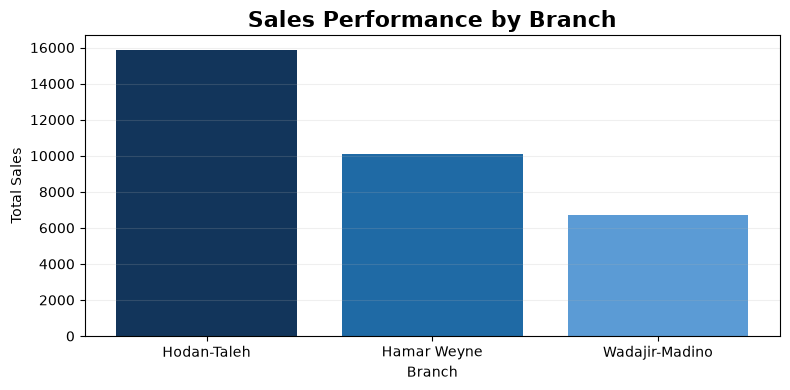

In [85]:
branch_sales = (
    df_clean.groupby("Branch")["Sales"]
    .sum()
    .sort_values(ascending=False))

colors = [
    "#12355B",
    "#1F6AA5",
    "#5B9BD5",]

if len(branch_sales) > 4:
    colors += ["#6B7280", "#9CA3AF", "#D1D5DB"]
plt.figure(figsize=(8, 4))

plt.bar(
    branch_sales.index,
    branch_sales.values,
    color=colors[:len(branch_sales)])

plt.title("Sales Performance by Branch", fontsize=16, fontweight="bold")
plt.xlabel("Branch")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

### Chart interpretation
**Hodan-Taleh** is the strongest-performing branch, generating approximately **15,886.48** in sales and contributing about **48.6%** of total sales. This indicates that sales are highly concentrated in this branch, while the lower-performing branches may require closer review.

In [86]:
# 2️⃣ Sales by Category -Chart: Bar Chart-
# Question: Which category performs best?

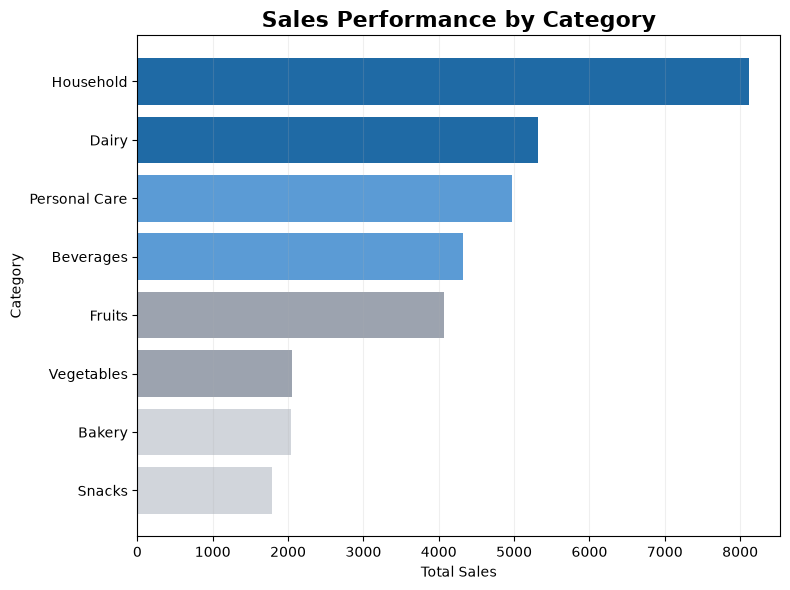

In [87]:
category_sales = (
    df_clean.groupby("Category")["Sales"]
    .sum().sort_values(ascending=True))

colors = [
    "#D1D5DB",
    "#D1D5DB",
    "#9CA3AF",
    "#9CA3AF",
    "#5B9BD5",
    "#5B9BD5",
    "#1F6AA5",
    "#1F6AA5",
    "#12355B",
    "#12355B"]

if len(category_sales) > 4:
    colors += ["#6B7280", "#9CA3AF", "#D1D5DB"]
plt.figure(figsize=(8, 6))

plt.barh(
    category_sales.index,
    category_sales.values,
    color=colors[:len(category_sales)])

plt.title("Sales Performance by Category", fontsize=16, fontweight="bold")
plt.xlabel("Total Sales")
plt.ylabel("Category")

plt.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

### Chart interpretation
The **Household** category leads sales at approximately **8,122.74**, followed by Dairy and Personal Care. Snacks is the lowest-performing category at approximately **1,789.52**, showing a meaningful difference in demand across product categories.

In [88]:
# 3️⃣ Top 10 Products by Sales -Chart: Horizontal Bar Chart-
# Question: Which products generate the highest sales?

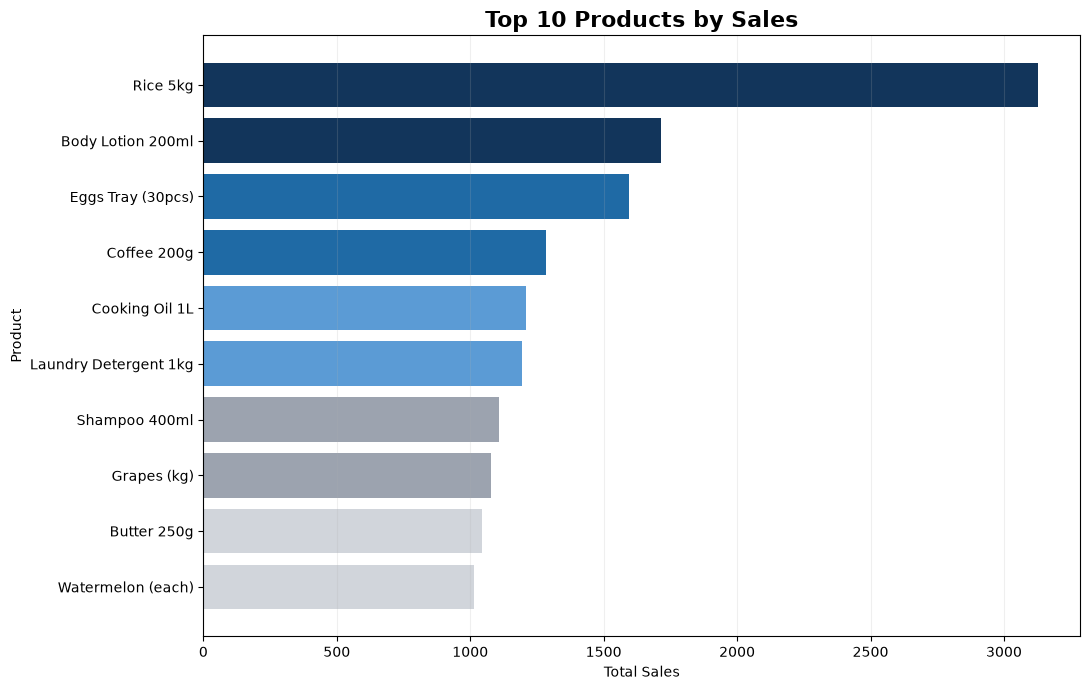

In [89]:
top_products = (
    df_clean.groupby("Product_Name")["Sales"]
    .sum().sort_values(ascending=False).head(10).sort_values(ascending=True))

product_colors = [
    "#D1D5DB",
    "#D1D5DB",
    "#9CA3AF",
    "#9CA3AF",
    "#5B9BD5",
    "#5B9BD5",
    "#1F6AA5",
    "#1F6AA5",
    "#12355B",
    "#12355B",]

plt.figure(figsize=(11, 7))

plt.barh(
    top_products.index,
    top_products.values,
    color=product_colors)

plt.title("Top 10 Products by Sales", fontsize=16, fontweight="bold")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

### Chart interpretation
**Rice 5kg** is the top-selling product, generating approximately **3,128.50** in sales. The ranking shows that a small group of products contributes strongly to revenue, making these products important for stock availability and promotion decisions.

In [90]:
# 4️⃣ Monthly Sales Trend -Chart: Line Chart-
# Question: How do sales change over time?

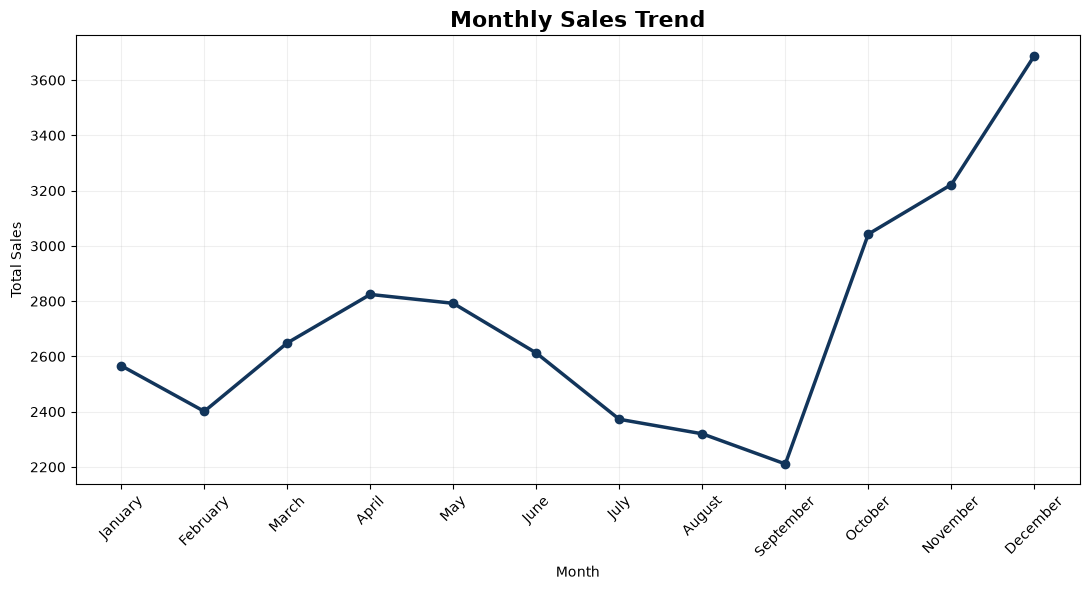

In [91]:
df_clean["Date"] = pd.to_datetime(df_clean["Date"])

df_clean["Month"] = df_clean["Date"].dt.month
df_clean["Month_Name"] = df_clean["Date"].dt.month_name()

monthly_sales = (
    df_clean.groupby(["Month", "Month_Name"])["Sales"]
    .sum()
    .reset_index()
    .sort_values("Month"))

plt.figure(figsize=(11, 6))

plt.plot(
    monthly_sales["Month_Name"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2.5,
    color="#12355B")

plt.title("Monthly Sales Trend", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Chart interpretation
Sales fluctuate during the year but increase strongly in the final quarter. **December** records the highest monthly sales at approximately **3,688.14**, while **September** is the lowest at approximately **2,210.76**, suggesting stronger demand toward year-end.

In [92]:
# 5️⃣ Payment Method Distribution -Chart: Donut Chart-
# Question: Which payment method is most preferred?

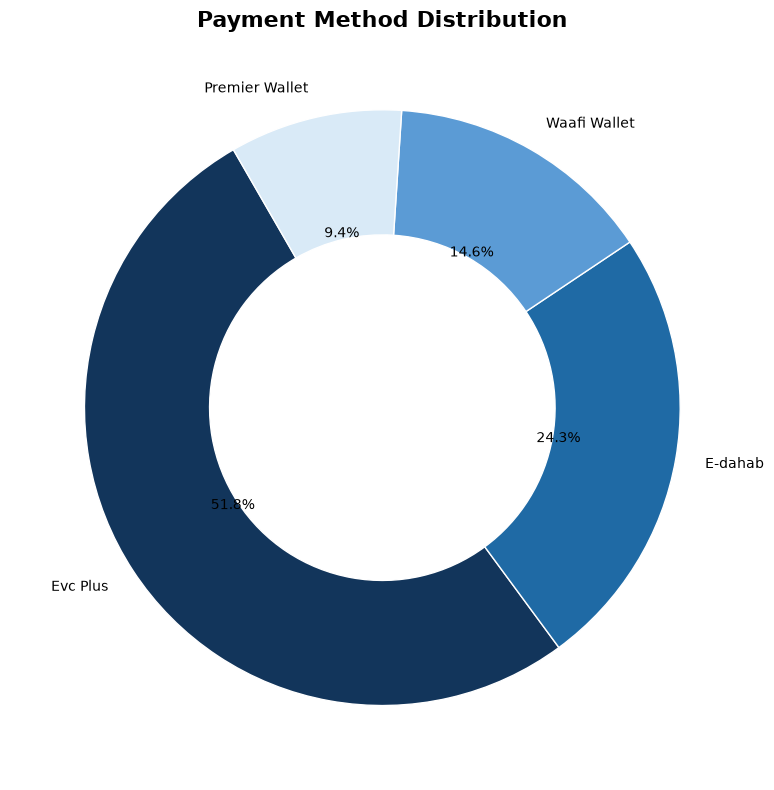

In [93]:
payment_counts = (
    df_clean["Payment_Method"]
    .value_counts())

payment_colors = [
    "#12355B",
    "#1F6AA5",
    "#5B9BD5",
    "#D9EAF7"]

if len(payment_counts) > 4:
    payment_colors += [
        "#6B7280",
        "#9CA3AF",
        "#D1D5DB"]

plt.figure(figsize=(8, 8))

plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    colors=payment_colors[:len(payment_counts)],
    autopct="%1.1f%%",
    startangle=120,
    wedgeprops=dict(width=0.42, edgecolor="white"))

plt.title(
    "Payment Method Distribution",
    fontsize=16,
    fontweight="bold")

plt.tight_layout()
plt.show()

### Chart interpretation
**EVC Plus** is the dominant payment method, accounting for approximately **51.8% of orders**, followed by E-dahab at about **24.3%**. This indicates a strong customer preference for mobile-wallet payments, particularly EVC Plus.

### Supporting Analysis Extra charts

These additional visualizations provide supporting customer and staff perspectives beyond the core business questions.

In [94]:
# 6 Total Sales by Customer Type - Pie chart
# Question: Which customer type generates the most sales?

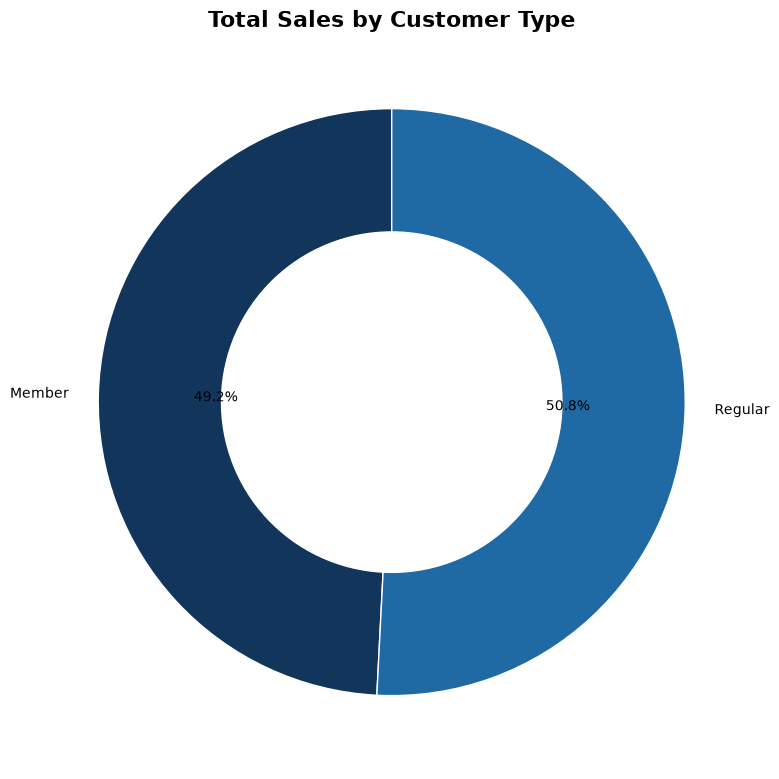

In [95]:
customer_sales = (
    df_clean.groupby("Customer_Type")["Sales"]
    .sum())

colors = [
    "#12355B",
    "#1F6AA5"]

plt.figure(figsize=(8, 8))

plt.pie(
    customer_sales.values,
    labels=customer_sales.index,
    colors=colors[:len(customer_sales)],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.42, edgecolor="white"))

plt.title(
    "Total Sales by Customer Type",
    fontsize=16,
    fontweight="bold")

plt.tight_layout()
plt.show()

### Chart interpretation
This chart compares the contribution of each customer type to total sales. The largest slice represents the customer segment generating the greatest share of revenue, which can help management prioritize retention and promotional strategies.

In [96]:
# 7. Total Orders by Gender — Pie Chart
# Question: Which gender contributes more orders?

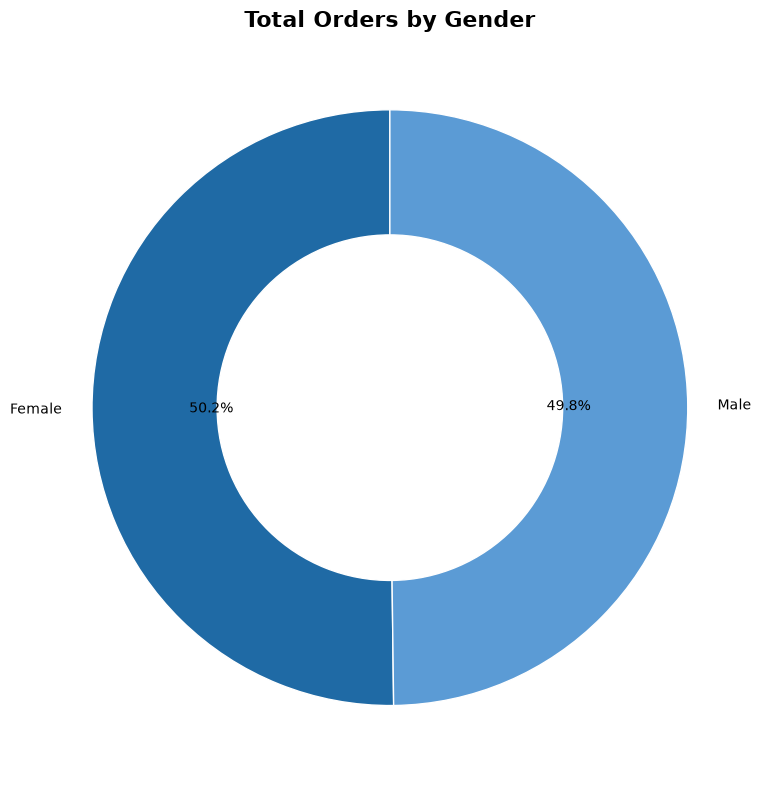

In [97]:
gender_orders = (
    df_clean.groupby("Gender")["Invoice_ID"]
    .nunique())

colors = [
    "#1F6AA5",
    "#5B9BD5",]

plt.figure(figsize=(8, 8))

plt.pie(
    gender_orders.values,
    labels=gender_orders.index,
    colors=colors[:len(gender_orders)],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.42, edgecolor="white"))

plt.title(
    "Total Orders by Gender",
    fontsize=16,
    fontweight="bold")

plt.tight_layout()
plt.show()

### Chart interpretation
The chart shows the distribution of completed orders by gender. The larger segment represents the group contributing more orders, providing a simple view of the customer mix that can support future customer-focused analysis.

In [98]:
# 8. Total Sales by Cashier -Horizontal Bar-
# Question: Which cashier generates the highest sales?

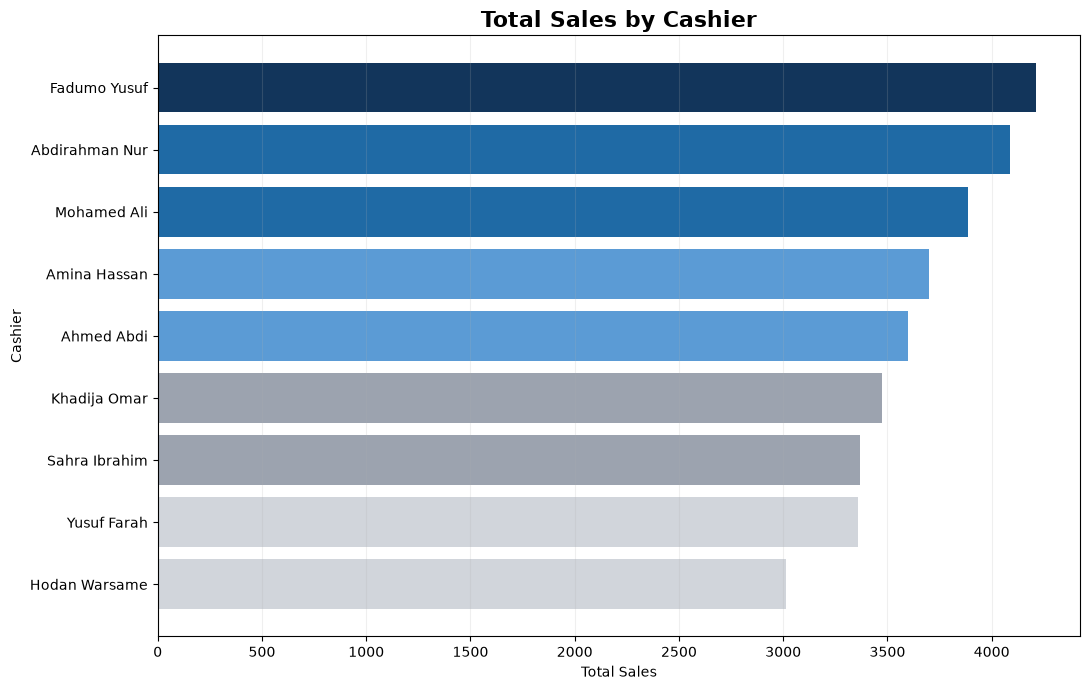

In [99]:
cashier_sales = (
    df_clean.groupby("Cashier")["Sales"]
    .sum()
    .sort_values(ascending=False))

cashier_colors = [
    "#D1D5DB",
    "#D1D5DB",
    "#9CA3AF",
    "#9CA3AF",
    "#5B9BD5",
    "#5B9BD5",
    "#1F6AA5",
    "#1F6AA5",
    "#12355B",
    "#12355B",]

plt.figure(figsize=(11, 7))

plt.barh(
    cashier_sales.index[::-1],
    cashier_sales.values[::-1],
    color=cashier_colors[:len(cashier_sales)])

plt.title("Total Sales by Cashier", fontsize=16, fontweight="bold")
plt.xlabel("Total Sales")
plt.ylabel("Cashier")

plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

### Chart interpretation
The cashier comparison highlights differences in sales handled across staff members. Higher-performing cashiers may provide useful operational benchmarks, while lower sales figures should be interpreted alongside branch assignment, working hours, and transaction volume rather than as a standalone measure of performance.

# 4.5 Communicate Insights

## Key Findings

1. **Branch concentration:** Hodan-Taleh generated approximately **15,886.48**, representing about **48.6% of total sales**. This makes it the main sales contributor and an important benchmark for the other branches.
2. **Category performance:** Household was the leading category with approximately **8,122.74** in sales, while Snacks was the lowest-performing category at approximately **1,789.52**.
3. **Product performance:** Rice 5kg was the top-selling product, generating approximately **3,128.50**. This highlights the importance of maintaining stock for high-demand staple products.
4. **Seasonality:** Sales strengthened significantly toward the end of the year. December was the strongest month at approximately **3,688.14**, while September was the weakest at approximately **2,210.76**.
5. **Payment preference:** EVC Plus represented about **51.8% of all orders**, making it the dominant payment method. E-dahab followed with about **24.3%**.

## Business Insights

The analysis indicates that Abyan Grocery's performance is not evenly distributed. One branch contributes almost half of total sales, while a small number of product categories and products account for a substantial share of revenue. The strong improvement in sales during the final quarter also suggests that customer demand may be affected by seasonal or year-end purchasing patterns.

The payment analysis shows that digital/mobile payments are important to customers, with EVC Plus clearly leading the payment mix. This is useful for operational planning because reliable support for preferred payment channels can reduce friction at checkout.

From a management perspective, the strongest opportunity is to learn from high-performing branches and products while investigating why lower-performing areas generate less revenue.

## Recommendations

- **Strengthen lower-performing branches:** Compare staffing, product availability, customer traffic, and operating practices with Hodan-Taleh to identify transferable best practices.
- **Protect high-demand products:** Maintain sufficient inventory for products such as Rice 5kg and other leading items to reduce the risk of stock-outs.
- **Review weaker categories:** Investigate whether low-performing categories need better product selection, pricing, placement, or promotion.
- **Prepare for seasonal demand:** Use the strong October–December performance as a signal to plan inventory and promotions ahead of high-demand periods.
- **Support preferred payment methods:** Ensure EVC Plus and other commonly used digital payment options remain reliable and easy for customers to use.